# Marginal versus joint smoothing

This compact tutorial fits the same dynamic diffusion model with Superstats' two smoothing approximations. The marginal approximator estimates each $v_t$ conditional on the observations and sampled invariants. The joint approximator additionally conditions each $v_t$ on the preceding trajectory.

In [ ]:
import numpy as np
import superstats as sup

In [4]:
NUM_STEPS = 100
TRAIN_SIZE = 20_000
VALIDATION_SIZE = 250
TEST_SIZE = 250
EPOCHS = 25
BATCH_SIZE = 32
NUM_SAMPLES = 250

## Model and shared simulations

In [5]:
joint_prior = sup.JointPrior(
    v=sup.transition.RandomWalk(),
    a=sup.transition.Linear(
        intercept=sup.Prior("normal", loc=2.0, scale=0.5),
        slope=sup.Prior("normal", loc=0.0, scale=1.0),
    ),
    tau=sup.Prior("halfnormal", scale=0.5),
    bias=0.5,
)

model = sup.Model(
    prior=joint_prior,
    simulator=sup.simulation.sample_ddm,
    latent_link_functions={
        "v": sup.LinkFunction("scaled_sigmoid", bounds=(-6.0, 6.0)),
        "a": sup.LinkFunction("clip", bounds=(0.2, 4.0)),
    },
    missing=None,
    contamination=None,
)

In [6]:
train_data = model.sample(batch_size=TRAIN_SIZE, num_steps=NUM_STEPS)
validation_data = model.sample(batch_size=VALIDATION_SIZE, num_steps=NUM_STEPS)
test_data = model.sample(batch_size=TEST_SIZE, num_steps=NUM_STEPS)

## Approximators

The string interface selects the approximation family. Both use Superstats' recurrent summary network and depth-2 spline coupling flows. Joint smoothing passes the shared summaries to BayesFlow's autoregressive decoder.

In [7]:
marginal_workflow = sup.Workflow(model=model, approximator="marginal", mode="smoothing")

joint_workflow = sup.Workflow(model=model, approximator="joint", mode="smoothing")

workflows = {"Marginal": marginal_workflow, "Joint": joint_workflow}

## Train and sample

Both workflows see the same simulations for the same number of optimizer updates. BayesFlow applies its default warm-started cosine-decay learning-rate schedule.

In [ ]:
histories = {}
for name, workflow in workflows.items():

    print(f"Training {name.lower()} smoother")
    histories[name] = workflow.fit_offline(
        data=train_data,
        validation_data=validation_data,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        save_history=False
    )

In [ ]:
posterior_samples = {
    name: workflow.sample(test_data, num_samples=NUM_SAMPLES, batch_size=4)
    for name, workflow in workflows.items()
}

## Time-varying verification

The same held-out trajectories are used for both diagnostic figures.

{'Marginal': {'correlation': np.float64(0.982),
  'nRMSE': np.float64(0.17),
  'contraction': np.float64(0.971),
  'calibration error': np.float64(0.018)},
 'Joint': {'correlation': np.float64(0.978),
  'nRMSE': np.float64(0.23),
  'contraction': np.float64(0.943),
  'calibration error': np.float64(0.028)}}

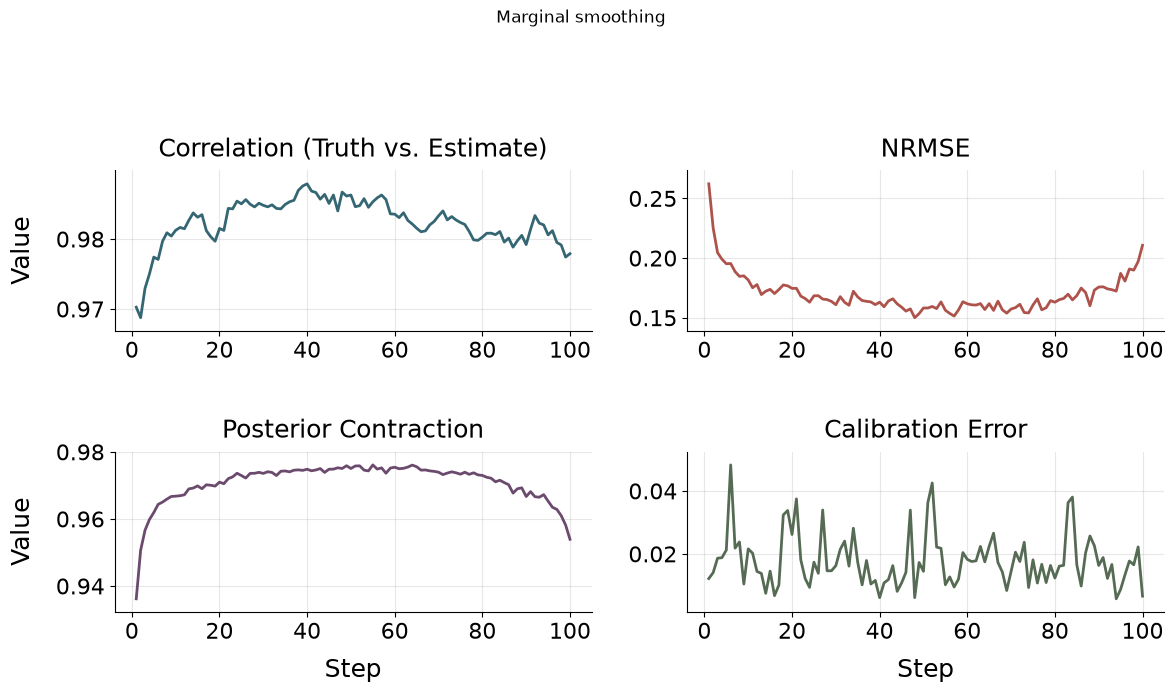

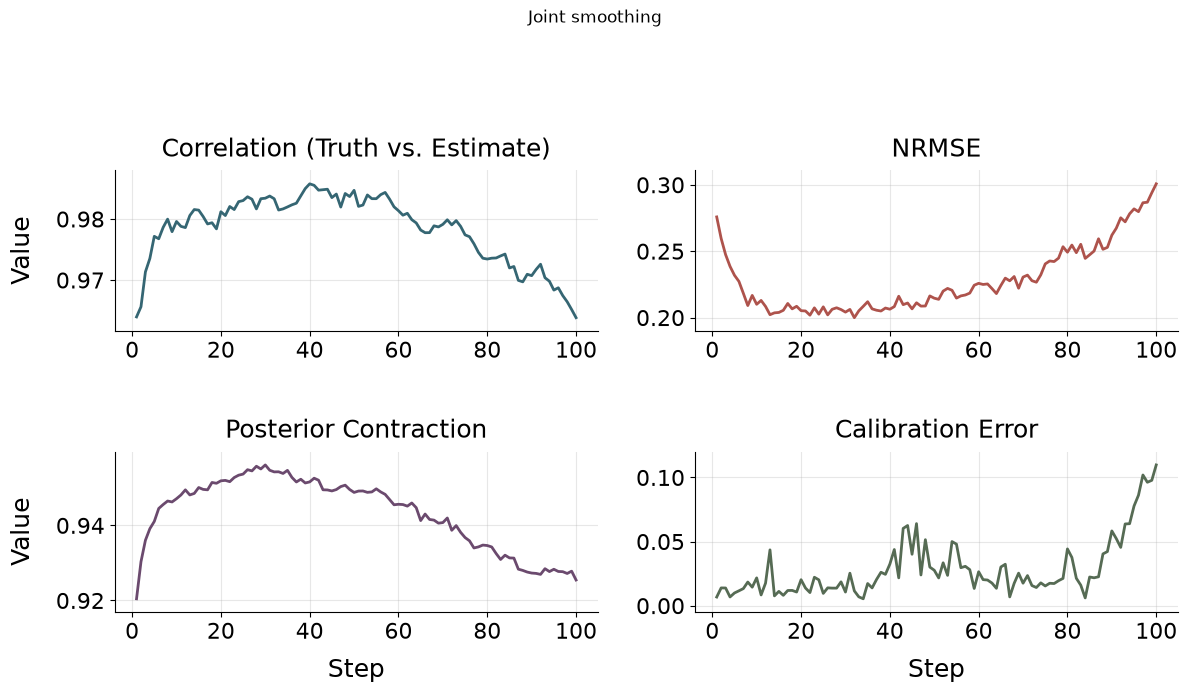

In [8]:
metric_summary = {}
for name, workflow in workflows.items():

    estimates = posterior_samples[name]["v"]
    targets = test_data["v"]

    metric_summary[name] = {
        "correlation": round(np.mean(sup.diagnostics.correlation_per_step(estimates, targets)), 3),
        "nRMSE": round(np.mean(sup.diagnostics.nrmse_per_step(estimates, targets)), 3),
        "contraction": round(np.mean(sup.diagnostics.posterior_contraction_per_step(estimates, targets)), 3),
        "calibration error": round(np.mean(sup.diagnostics.calibration_error_per_step(estimates, targets)), 3),
    }

    fig = workflow.verify_time_varying(
        targets=test_data,
        estimates=posterior_samples[name],
        variable_keys=["v"]
    )

    fig.suptitle(f"{name} smoothing", y=1.02)

metric_summary

## One estimated trajectory

Both panels show posterior uncertainty for the first held-out trajectory.

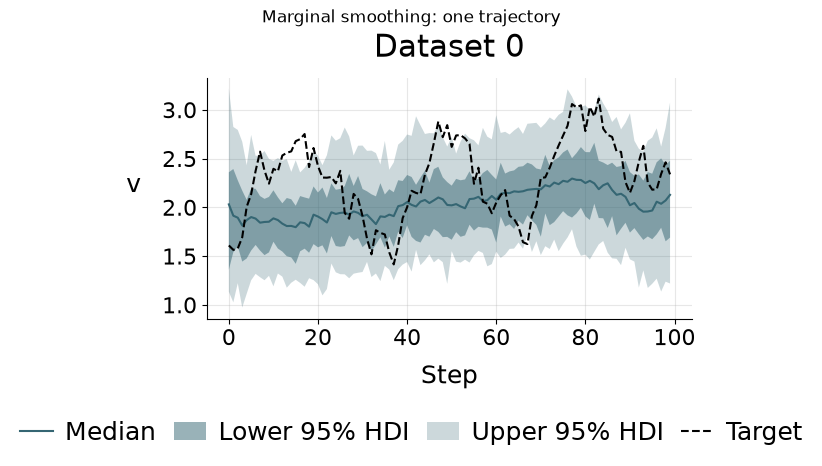

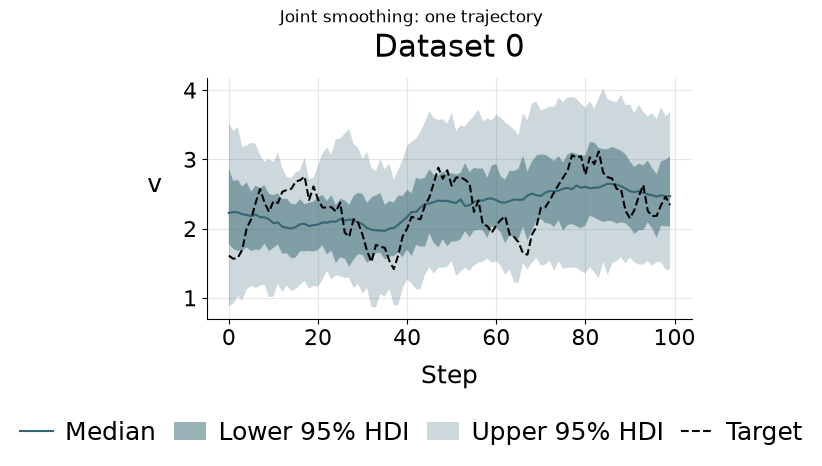

In [9]:
for name, workflow in workflows.items():
    fig = workflow.plot_time_varying_posterior(
        estimates=posterior_samples[name],
        targets=test_data,
        variable_keys=["v"],
        data_idx=0,
        marginal=False
    )
    fig.suptitle(f"{name} smoothing: one trajectory", y=1.02)